In [ ]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import loompy as lp
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import itertools
from ctxcore.genesig import GeneSignature
from pyscenic.aucell import aucell, derive_auc_threshold, create_rankings
from collections import defaultdict
from collections import Counter
from pyscenic.utils import load_motifs
from pyscenic.transform import df2regulons
from pyscenic.rss import regulon_specificity_scores
from pyscenic.plotting import plot_rss
from adjustText import adjust_text
from pyscenic.binarization import binarize
import decoupler as dc
import decoupler as dc

: 

In [2]:
os.chdir("/global/scratch/users/kenchen/LAM/5_regulon/reg_results/pyscenic_runs")

In [ ]:
sc.settings.set_figure_params(dpi=200, frameon=False)
sc.set_figure_params(dpi=200)
sc.set_figure_params(figsize=(8, 8))

In [3]:
lam_ctrl = sc.read_h5ad("../../converted/lam_ctrl.h5ad")
lam_ut = sc.read_h5ad("../../converted/lam_ut.h5ad")
motif_10kbp = pd.read_feather("pyscenic_files/motifs/rankings/hg38_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather")

In [ ]:
#filter to genes in feather files and expressed in >=10 cells
motif_genes = motif_10kbp.columns[:-1]
motif_genes = [name for name in lam_ctrl.var_names if name in motif_genes]
lam_ctrl_motif = lam_ctrl[:, motif_genes]
sc.pp.filter_genes(lam_ctrl_motif, min_cells=10 )

In [ ]:
f_loom_path_scenic = "lam_ctrl10.loom"
row_attrs = {
    "Gene": np.array(lam_ctrl_motif.var_names) ,
}
col_attrs = {
    "CellID": np.array(lam_ctrl_motif.obs_names) ,
    "nGene": np.array( np.sum(lam_ctrl_motif.X.transpose()>0 , axis=0)).flatten() ,
    "nUMI": np.array( np.sum(lam_ctrl_motif.X.transpose() , axis=0)).flatten() ,
}
lp.create( f_loom_path_scenic, lam_ctrl_motif.X.transpose(), row_attrs, col_attrs)

In [160]:
f_loom_path_scenic = "lam_ctrl.loom"
row_attrs = {
    "Gene": np.array(lam_ctrl.var_names) ,
}
col_attrs = {
    "CellID": np.array(lam_ctrl.obs_names) ,
    "nGene": np.array( np.sum(lam_ctrl.X.transpose()>0 , axis=0)).flatten() ,
    "nUMI": np.array( np.sum(lam_ctrl.X.transpose() , axis=0)).flatten() ,
}
lp.create( f_loom_path_scenic, lam_ctrl.X.transpose(), row_attrs, col_attrs)

In [ ]:
f_loom_path_scenic = "lam_ut.loom"
row_attrs = {
    "Gene": np.array(lam_ut.var_names) ,
}
col_attrs = {
    "CellID": np.array(lam_ut.obs_names) ,
    "nGene": np.array( np.sum(lam_ut.X.transpose()>0 , axis=0)).flatten() ,
    "nUMI": np.array( np.sum(lam_ut.X.transpose() , axis=0)).flatten() ,
}
lp.create( f_loom_path_scenic, lam_ut.X.transpose(), row_attrs, col_attrs)

pyscenic grn, ctx, aucell

AGGREGATE REGULONS

In [ ]:
pyscenic_loom_1 = lp.connect("output_1.loom", mode='r', validate=False)
pyscenic_loom_2 = lp.connect("output_2.loom", mode='r', validate=False)
pyscenic_loom_3 = lp.connect("output_3.loom", mode='r', validate=False)
pyscenic_loom_4 = lp.connect("output_4.loom", mode='r', validate=False)
pyscenic_loom_5 = lp.connect("output_5.loom", mode='r', validate=False)
pyscenic_loom_6 = lp.connect("output_6.loom", mode='r', validate=False)
pyscenic_loom_7 = lp.connect("output_7.loom", mode='r', validate=False)
pyscenic_loom_8 = lp.connect("output_8.loom", mode='r', validate=False)
pyscenic_loom_9 = lp.connect("output_9.loom", mode='r', validate=False)
pyscenic_loom_10 = lp.connect("output_10.loom", mode='r', validate=False)

In [ ]:
regulons_1 = {}
for i,r in pd.DataFrame(pyscenic_loom_1.ra.Regulons,index=pyscenic_loom_1.ra.Gene).iteritems():
    regulons_1[i] =  list(r[r==1].index.values)
regulons_2 = {}
for i,r in pd.DataFrame(pyscenic_loom_2.ra.Regulons,index=pyscenic_loom_2.ra.Gene).iteritems():
    regulons_2[i] =  list(r[r==1].index.values)
regulons_3 = {}
for i,r in pd.DataFrame(pyscenic_loom_3.ra.Regulons,index=pyscenic_loom_3.ra.Gene).iteritems():
    regulons_3[i] =  list(r[r==1].index.values)
regulons_4 = {}
for i,r in pd.DataFrame(pyscenic_loom_4.ra.Regulons,index=pyscenic_loom_4.ra.Gene).iteritems():
    regulons_4[i] =  list(r[r==1].index.values)
regulons_5 = {}
for i,r in pd.DataFrame(pyscenic_loom_5.ra.Regulons,index=pyscenic_loom_5.ra.Gene).iteritems():
    regulons_5[i] =  list(r[r==1].index.values)
regulons_6 = {}
for i,r in pd.DataFrame(pyscenic_loom_6.ra.Regulons,index=pyscenic_loom_6.ra.Gene).iteritems():
    regulons_6[i] =  list(r[r==1].index.values)
regulons_7 = {}
for i,r in pd.DataFrame(pyscenic_loom_7.ra.Regulons,index=pyscenic_loom_7.ra.Gene).iteritems():
    regulons_7[i] =  list(r[r==1].index.values)
regulons_8 = {}
for i,r in pd.DataFrame(pyscenic_loom_8.ra.Regulons,index=pyscenic_loom_8.ra.Gene).iteritems():
    regulons_8[i] =  list(r[r==1].index.values)
regulons_9 = {}
for i,r in pd.DataFrame(pyscenic_loom_9.ra.Regulons,index=pyscenic_loom_9.ra.Gene).iteritems():
    regulons_9[i] =  list(r[r==1].index.values)
regulons_10 = {}
for i,r in pd.DataFrame(pyscenic_loom_10.ra.Regulons,index=pyscenic_loom_10.ra.Gene).iteritems():
    regulons_10[i] =  list(r[r==1].index.values)

In [ ]:
all_regs = list(regulons_1.keys())+list(regulons_2.keys())+list(regulons_3.keys())+list(regulons_4.keys()) \
    +list(regulons_5.keys())+list(regulons_6.keys())+list(regulons_7.keys())+list(regulons_8.keys()) \
    +list(regulons_9.keys())+list(regulons_10.keys())
reg_counts = np.unique(all_regs, return_counts=True)
#regulons appearing in 7+ runs
reg_sel = list(reg_counts[0][reg_counts[1]>=7])

In [ ]:
ll_regs = [list(regulons_1.keys()),list(regulons_2.keys()),list(regulons_3.keys()),list(regulons_4.keys()),list(regulons_5.keys()),
          list(regulons_6.keys()),list(regulons_7.keys()),list(regulons_8.keys()),list(regulons_9.keys()),list(regulons_10.keys()),]
pd.DataFrame(np.array(list(itertools.zip_longest(*ll_regs, fillvalue=np.nan))).T).to_csv("all_run_tfs.csv", sep="\t")

In [ ]:
dd = defaultdict(list)

for d in (regulons_1, regulons_2, regulons_3, regulons_4, regulons_5, regulons_6, regulons_7, regulons_8, regulons_9, regulons_10):
    for key, value in d.items():
        #dd[key].append(value)
        dd[key]=dd[key]+value

dict_sel = {key: dd[key] for key in reg_sel}
length_dict = {key: len(value) for key, value in dict_sel.items()}

In [ ]:
#keep target genes appearing in 7+ runs
reg_target_sel={}
for key, value in dict_sel.items():
    counts = np.unique(value, return_counts=True)
    reg_target_sel[key] = list(counts[0][counts[1]>=7])
    if len(reg_target_sel[key]) < 1:  #number of target genes filter
        del reg_target_sel[key]

In [ ]:
reg_target_sel

In [ ]:
#reformat for collectri
dc_format = []

for source, targets in reg_target_sel.items():
    source = source.replace('(+)','')
    for target in targets:
        dc_format.append([source, target])
dc_format = pd.DataFrame(dc_format, columns=['source', 'target'])
dc_format['weight'] = 1

In [ ]:
dc_format.to_csv("sc_agg_fordc.tsv", sep="\t")

In [ ]:
with open('agg_reg.gmt', 'wt') as gmt:
    for c in list(reg_target_sel.items()):
        genes='\t'.join(c[1])
        gmt.write(f'{c[0]}\tRegulon_{c[0]}\t{genes}\n')
signatures = GeneSignature.from_gmt('agg_reg.gmt', field_separator='\t', gene_separator='\t')

In [31]:
signatures

[GeneSignature(name='ARID3A(+)', gene2weight=frozendict.frozendict({'ARID3A': 1.0, 'C1QTNF5': 1.0, 'CDH22': 1.0, 'KCNH1': 1.0, 'LINC00222': 1.0, 'LRRC20': 1.0, 'MMP17': 1.0, 'MYL3': 1.0, 'OGFR-AS1': 1.0, 'SLC12A9': 1.0, 'SLC4A3': 1.0, 'TULP1': 1.0, 'YIPF7': 1.0})),
 GeneSignature(name='ASCL1(+)', gene2weight=frozendict.frozendict({'DPP10': 1.0, 'FBXL16': 1.0, 'KCNB2': 1.0, 'LINGO2': 1.0, 'NRXN1': 1.0, 'SYT1': 1.0, 'SYT14': 1.0})),
 GeneSignature(name='ATF1(+)', gene2weight=frozendict.frozendict({'ATF1': 1.0, 'C10orf105': 1.0, 'EPS8L3': 1.0, 'GHRLOS': 1.0, 'GRPR': 1.0, 'H19': 1.0, 'LINGO1': 1.0, 'WDR72': 1.0})),
 GeneSignature(name='ATF3(+)', gene2weight=frozendict.frozendict({'ADRB2': 1.0, 'ALDOA': 1.0, 'AMOTL2': 1.0, 'ANKRD37': 1.0, 'ANXA1': 1.0, 'ARF4': 1.0, 'ARG2': 1.0, 'ATF3': 1.0, 'AZIN2': 1.0, 'BEST1': 1.0, 'BRD2': 1.0, 'BTG2': 1.0, 'C16orf72': 1.0, 'CBX4': 1.0, 'CDKN1A': 1.0, 'CDKN2AIP': 1.0, 'CHAC1': 1.0, 'CXCL1': 1.0, 'CXCL8': 1.0, 'DDIT3': 1.0, 'DEDD2': 1.0, 'DLGAP1-AS2': 1.0

DECOUPLER

In [5]:
os.chdir("../combined")

In [34]:
collectri = dc.get_collectri(organism='human', split_complexes=False)

In [38]:
#match collectri symbols to gene symbols used in object
regulon_symbol = pd.read_csv("../regulon_symbol.txt", sep="\t")
collectri['source'] = collectri['source'].map(regulon_symbol.set_index('collectri_symbol')['symbol']).fillna(collectri['source'])
collectri['target'] = collectri['target'].map(regulon_symbol.set_index('collectri_symbol')['symbol']).fillna(collectri['target'])

In [112]:
#filter collectri table - source in acts + target in seurat
collectri_filt = collectri[(collectri["source"].isin(lam_ctrl.var.index)) & (collectri["target"].isin(lam_ctrl.var.index))]
collectri_filt

,source,target,weight
0,MYC,TERT,1
1,SPI1,BGLAP,1
2,SMAD3,JUN,1
3,SMAD4,JUN,1
4,STAT5A,IL2,1
...,...,...,...
41663,RUNX1,LCP2,1
41664,RUNX1,PRR5L,1
41665,TWIST1,GLI1,1
41666,USF1,NUP188,1


In [113]:
sc_agg_filt = dc_format[~dc_format.apply(lambda row: ((collectri_filt['source'] == row['source']) & 
                                                    (collectri_filt['target'] == row['target'])).any(), axis=1)]
                                                    
sc_agg_filt = sc_agg_filt[(sc_agg_filt["source"].isin(lam_ctrl.var.index)) & (sc_agg_filt["target"].isin(lam_ctrl.var.index))]

In [114]:
comb_reg_dc = pd.concat([collectri_filt, sc_agg_filt], ignore_index=True)

In [115]:
#keep only regs with >=5 positive targets
comb_reg_pos = comb_reg_dc[comb_reg_dc['weight'] == 1]
source_counts = comb_reg_pos['source'].value_counts()
comb_reg_dc = comb_reg_dc[comb_reg_dc['source'].isin(source_counts[source_counts >= 5].index)]

In [120]:
print(len(comb_reg_dc["source"].unique()))

740


In [121]:
dc.run_ulm(
    mat=lam_ctrl,
    net=comb_reg_dc,
    source='source',
    target='target',
    weight='weight',
    verbose=True,
    use_raw=False
)
#save output in obsm
lam_ctrl.obsm['comb_ulm_estimate'] = lam_ctrl.obsm['ulm_estimate'].copy()
lam_ctrl.obsm['comb_ulm_pvals'] = lam_ctrl.obsm['ulm_pvals'].copy()

1837 features of mat are empty, they will be removed.
Running ulm on mat with 76876 samples and 30447 targets for 738 sources.


100%|██████████| 8/8 [11:09<00:00, 83.73s/it]


In [ ]:
dc.run_ulm(
    mat=lam_ut,
    net=comb_reg_dc,
    source='source',
    target='target',
    weight='weight',
    verbose=True,
    use_raw=False
)
#save output in obsm
lam_ut.obsm['comb_ulm_estimate'] = lam_ut.obsm['ulm_estimate'].copy()
lam_ut.obsm['comb_ulm_pvals'] = lam_ut.obsm['ulm_pvals'].copy()

In [122]:
comb_acts = dc.get_acts(lam_ctrl, obsm_key='comb_ulm_estimate')
comb_reg_dc_filt = comb_reg_dc[(comb_reg_dc["source"].isin(comb_acts.var.index))]
comb_reg_dc_filt.to_csv("comb_reg_dc_filt.txt", sep="\t", index=False)
comb_acts.obsm["comb_ulm_estimate"].to_csv("comb_acts.txt", sep="\t", index=True)
comb_acts_ut = dc.get_acts(lam_ut, obsm_key='comb_ulm_estimate')
comb_acts_ut.obsm["comb_ulm_estimate"].to_csv("comb_acts_ut.txt", sep="\t", index=True)

In [123]:
collectri_filt = collectri_filt.merge(comb_reg_dc_filt, how='inner')
sc_agg_filt = sc_agg_filt.merge(comb_reg_dc_filt, how='inner')

In [124]:
print(len(set(comb_reg_dc_filt['source']).intersection(set(sc_agg_filt['source']))))
print(len(set(comb_reg_dc_filt['source']).intersection(set(collectri_filt['source']))))

274
730


In [125]:
collectri_dict = {}

# Iterate through the DataFrame
for index, row in collectri_filt.iterrows():
    source = row['source']
    target = row['target']
    weight = row['weight']

    # Check if the source is already a key in the dictionary
    if source not in collectri_dict:
        # If not, add the source as a key with two empty lists
        collectri_dict[source] = [[], []]

    # Append the target to the corresponding list based on the weight
    if weight == 1:
        collectri_dict[source][0].append(target)
    elif weight == -1:
        collectri_dict[source][1].append(target)

for key in collectri_dict:
    collectri_dict[key][0] = sorted(collectri_dict[key][0])
    collectri_dict[key][1] = sorted(collectri_dict[key][1])

result_df = pd.DataFrame.from_dict(collectri_dict, orient='index', columns=['Targets with Weight=1', 'Targets with Weight=-1'])
result_df.reset_index(inplace=True)
result_df.rename(columns={'index': 'Source'}, inplace=True)
result_df['Targets with Weight=1'] = result_df['Targets with Weight=1'].apply(lambda x: ', '.join(map(str, x)))
result_df['Targets with Weight=-1'] = result_df['Targets with Weight=-1'].apply(lambda x: ', '.join(map(str, x)))
result_df.to_csv("collectri_regulons.txt", sep="\t", index=False)

In [126]:
comb_dict = {}
for index, row in comb_reg_dc_filt.iterrows():
    source = row['source']
    target = row['target']
    weight = row['weight']
    if source not in comb_dict:
        comb_dict[source] = [[], []]
    if weight == 1:
        comb_dict[source][0].append(target)
    elif weight == -1:
        comb_dict[source][1].append(target)
        
for key in comb_dict:
    comb_dict[key][0] = sorted(comb_dict[key][0])
    comb_dict[key][1] = sorted(comb_dict[key][1])

comb_df = pd.DataFrame.from_dict(comb_dict, orient='index', columns=['Targets with Weight=1', 'Targets with Weight=-1'])
comb_df.reset_index(inplace=True)
comb_df.rename(columns={'index': 'Source'}, inplace=True)
comb_df['Targets with Weight=1'] = comb_df['Targets with Weight=1'].apply(lambda x: ', '.join(map(str, x)))
comb_df['Targets with Weight=-1'] = comb_df['Targets with Weight=-1'].apply(lambda x: ', '.join(map(str, x)))
comb_df.to_csv("comb_regulons.txt", sep="\t", index=False)

In [127]:
sc_dict = {}
for index, row in sc_agg_filt.iterrows():
    source = row['source']
    target = row['target']
    weight = row['weight']
    if source not in sc_dict:
        sc_dict[source] = [[], []]
    if weight == 1:
        sc_dict[source][0].append(target)
    elif weight == -1:
        sc_dict[source][1].append(target)
        
for key in sc_dict:
    sc_dict[key][0] = sorted(sc_dict[key][0])
    sc_dict[key][1] = sorted(sc_dict[key][1])

sc_df = pd.DataFrame.from_dict(sc_dict, orient='index', columns=['Targets with Weight=1', 'Targets with Weight=-1'])
sc_df.reset_index(inplace=True)
sc_df.rename(columns={'index': 'Source'}, inplace=True)
sc_df['Targets with Weight=1'] = sc_df['Targets with Weight=1'].apply(lambda x: ', '.join(map(str, x)))
sc_df['Targets with Weight=-1'] = sc_df['Targets with Weight=-1'].apply(lambda x: ', '.join(map(str, x)))
sc_df.to_csv("sc_regulons.txt", sep="\t", index=False)

pySCENIC Analysis

In [100]:
reg_target_sel

{'ARID3A(+)': ['ARID3A',
  'C1QTNF5',
  'CDH22',
  'KCNH1',
  'LINC00222',
  'LRRC20',
  'MMP17',
  'MYL3',
  'OGFR-AS1',
  'SLC12A9',
  'SLC4A3',
  'TULP1',
  'YIPF7'],
 'ASCL1(+)': ['DPP10', 'FBXL16', 'KCNB2', 'LINGO2', 'NRXN1', 'SYT1', 'SYT14'],
 'ATF1(+)': ['ATF1',
  'C10orf105',
  'EPS8L3',
  'GHRLOS',
  'GRPR',
  'H19',
  'LINGO1',
  'WDR72'],
 'ATF3(+)': ['ADRB2',
  'ALDOA',
  'AMOTL2',
  'ANKRD37',
  'ANXA1',
  'ARF4',
  'ARG2',
  'ATF3',
  'AZIN2',
  'BEST1',
  'BRD2',
  'BTG2',
  'C16orf72',
  'CBX4',
  'CDKN1A',
  'CDKN2AIP',
  'CHAC1',
  'CXCL1',
  'CXCL8',
  'DDIT3',
  'DEDD2',
  'DLGAP1-AS2',
  'DNAJA1',
  'DNAJB1',
  'DUSP1',
  'DUSP10',
  'DUSP5',
  'EGR1',
  'EGR2',
  'EGR3',
  'EPHA2',
  'EPHB3',
  'ERRFI1',
  'ETF1',
  'FKBP2',
  'FN3K',
  'FOS',
  'FOSB',
  'GADD45B',
  'GAS5',
  'GET4',
  'GLUD1',
  'GLUL',
  'GNPTG',
  'GTF2B',
  'HBEGF',
  'HELT',
  'HGS',
  'HIST3H2BB',
  'HNRNPL',
  'HSP90AA1',
  'HSP90AB1',
  'HSPA1A',
  'HSPA1B',
  'HSPH1',
  'IER2',
  'IER3'

In [128]:
comb_reg_pos = comb_reg_dc_filt[comb_reg_dc_filt['weight'] == 1]
comb_reg_pos

,source,target,weight
0,MYC,TERT,1
1,SPI1,BGLAP,1
2,SMAD3,JUN,1
3,SMAD4,JUN,1
4,STAT5A,IL2,1
...,...,...,...
62660,ZNF407,ZSCAN5A,1
62661,ZNF407,ZSWIM6,1
62663,ZNF436,PIGZ,1
62664,ZNF436,ZMYM3,1


In [131]:
comb_reg_pos = comb_reg_pos.drop(columns='weight')
comb_reg_sc = comb_reg_pos.groupby('source')['target'].apply(list).to_dict()
comb_reg_sc

{'ABL1': ['JUN', 'TP53', 'BAX', 'CCND2', 'CDKN1A', 'CSF1', 'FOXO3', 'PIM1'],
 'AHR': ['CYP1B1',
  'ALDH3A1',
  'CYP1A1',
  'CDKN1B',
  'CTSD',
  'AHR',
  'GHRHR',
  'TF',
  'RB1',
  'ACHE',
  'XPO1',
  'CREBBP',
  'MDM2',
  'CD40',
  'ABCB1',
  'MYC',
  'ARNT',
  'UGT1A6',
  'BAX',
  'TNF',
  'STAR',
  'POLK',
  'AHRR',
  'SMARCA4',
  'GCG',
  'ALB',
  'GSTM1',
  'SERPINE1',
  'PTGS2',
  'SIM1',
  'IL6',
  'MMP1',
  'CDKN2A',
  'ATM',
  'TNFRSF11A',
  'ESR2',
  'ESR1',
  'PON1',
  'FASLG',
  'IGKV2D-26',
  'BTK',
  'CD2',
  'NFE2L2',
  'UGT1A7',
  'SDHB',
  'UGT1A1',
  'EREG',
  'NRIP1',
  'INSM1',
  'CAD',
  'GUCY1A1',
  'SNAI2',
  'FST',
  'CDKN2B',
  'TP53',
  'AIP',
  'CBR1',
  'FGFR1',
  'L1CAM',
  'CXCL8',
  'PDLIM7',
  'IGFBP1',
  'PPIG',
  'EGLN1',
  'THBS1',
  'APAF1',
  'CRYAB',
  'HSP90AB1',
  'SMOC2',
  'FSCN1',
  'FGF9',
  'PHB2',
  'TH',
  'AGR2',
  'CD36',
  'ABCC4',
  'RFC1',
  'ABCG2',
  'CAT',
  'SOD1',
  'CYP19A1',
  'SOS1',
  'IL17A',
  'WIF1',
  'PPARGC1B',
  'MFSD

In [6]:
with open('comb_reg.gmt', 'wt') as gmt:
    for c in list(comb_reg_sc.items()):
        genes='\t'.join(c[1])
        gmt.write(f'{c[0]}\tRegulon_{c[0]}\t{genes}\n')
signatures = GeneSignature.from_gmt('comb_reg.gmt', field_separator='\t', gene_separator='\t')

ANALYSIS ON AGGREGATED REGULONS

In [7]:
lam_ctrl_loom = lp.connect("../pyscenic_runs/lam_ctrl.loom", mode='r', validate=False)
exprMat = pd.DataFrame( lam_ctrl_loom[:,:], index=lam_ctrl_loom.ra.Gene, columns=lam_ctrl_loom.ca.CellID).T
auc_mtx = aucell(exprMat, signatures, num_workers=20)
auc_mtx.to_csv("auc_mtx_agg.tsv", sep="\t")

In [ ]:
lam_ut_loom = lp.connect("../pyscenic_runs/lam_ut.loom", mode='r', validate=False)
exprMat_ut = pd.DataFrame( lam_ut_loom[:,:], index=lam_ut_loom.ra.Gene, columns=lam_ut_loom.ca.CellID).T
auc_mtx_ut = aucell(exprMat_ut, signatures, num_workers=20)
auc_mtx_ut.to_csv("auc_mtx_agg_ut.tsv", sep="\t")

REGULON SPECIFITY SCORE SHIT

In [8]:
auc_mtx.index

Index(['LAM1_scRNA_AAACCTGAGCTGAAAT-1', 'LAM1_scRNA_AAACCTGGTAAATGTG-1',
       'LAM1_scRNA_AAACCTGGTCGTGGCT-1', 'LAM1_scRNA_AAACCTGGTGAACCTT-1',
       'LAM1_scRNA_AAACGGGAGATCCCGC-1', 'LAM1_scRNA_AAACGGGAGTACCGGA-1',
       'LAM1_scRNA_AAACGGGCAATAACGA-1', 'LAM1_scRNA_AAACGGGTCCTCATTA-1',
       'LAM1_scRNA_AAACGGGTCGGGAGTA-1', 'LAM1_scRNA_AAAGATGAGACTAAGT-1',
       ...
       'C54ctr_AAGAACAAGTTCCGGC-1', 'C54ctr_GTCCACTTCCATCGTC-1',
       'C54ctr_TATCTGTGTAGAATGT-1', 'C54ctr_CGCGTGAGTCCAATCA-1',
       'C54ctr_GTAGATCCAGTTTCGA-1', 'C54ctr_CGTGAATAGAGGGTAA-1',
       'C54ctr_TCTCTGGGTTTCCATT-1', 'C54ctr_AGAGCCCAGGATCATA-1',
       'C54ctr_AGACCCGGTGTTAAAG-1', 'C54ctr_GAATAGATCTCTCAAT-1'],
      dtype='object', name='Cell', length=76876)

In [20]:
lam_ctrl_lam = lam_ctrl.obs[lam_ctrl.obs['Diagnosis'] == "LAM"]
cellAnnot_lam = pd.DataFrame(lam_ctrl_lam['celltype_011625'])

# Filter auc_mtx to only include the cells that are in lam_ctrl_lam
auc_mtx_lam = auc_mtx.loc[lam_ctrl_lam.index, :]   # Assuming auc_mtx is a matrix where rows are cells

# Compute regulon specificity scores for the filtered auc_mtx and cellAnnot_lam
rss_cellType_lam = regulon_specificity_scores(auc_mtx_lam, cellAnnot_lam['celltype_011625'])

# Save the result to a file
rss_cellType_lam.to_csv("reg_rss_lam.txt", sep="\t", index=True)

In [ ]:
cellAnnot_ut = pd.DataFrame(lam_ut.obs['celltype_4'])
# Compute regulon specificity scores for the filtered auc_mtx and cellAnnot_lam
rss_cellType_ut = regulon_specificity_scores(auc_mtx_ut, cellAnnot_ut['celltype_4'])

# Save the result to a file
rss_cellType_ut.to_csv("reg_rss_ut.txt", sep="\t", index=True)

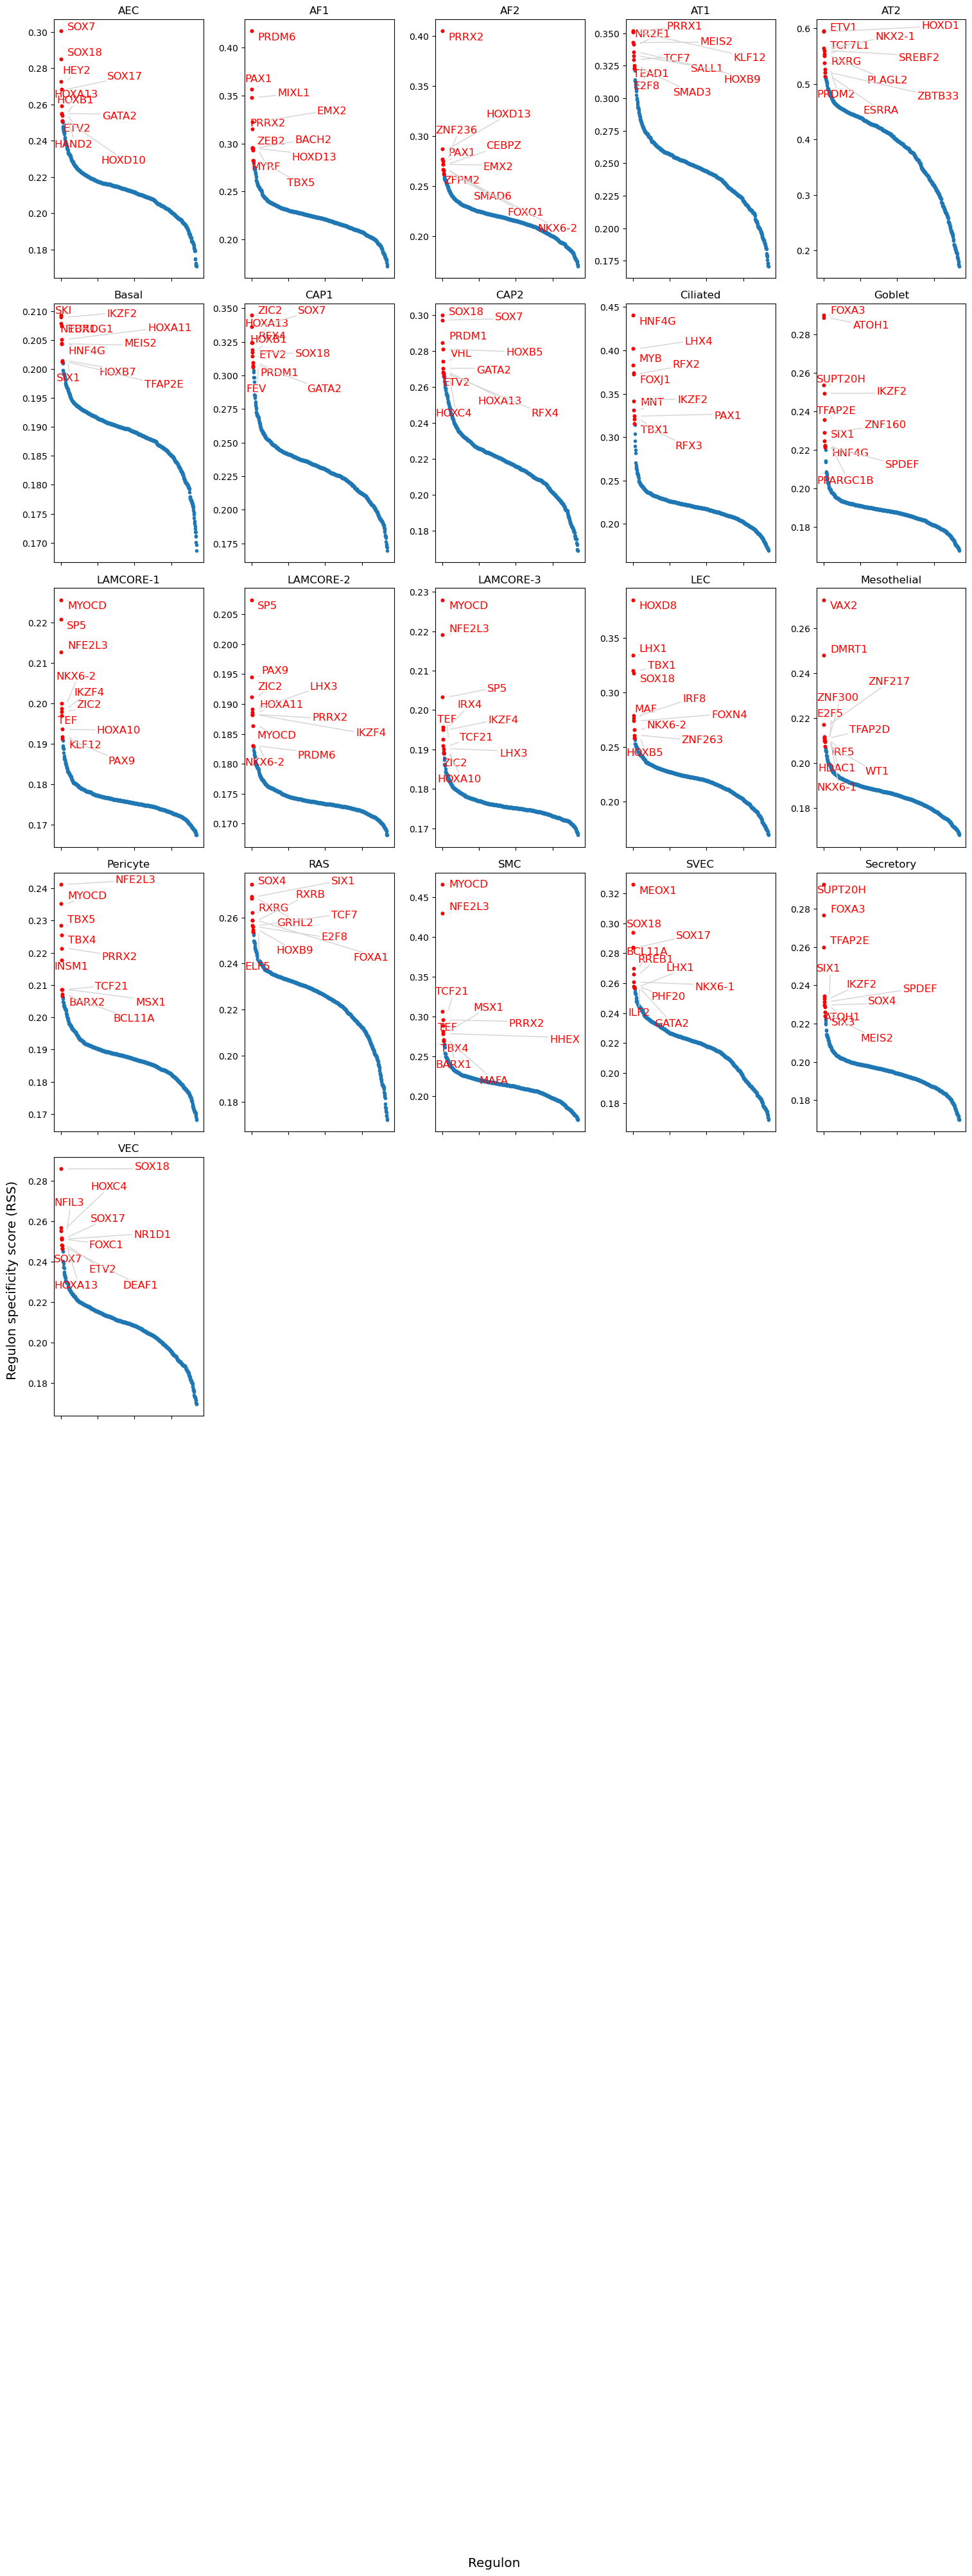

In [22]:
cats = sorted(list(set(cellAnnot_lam['celltype_011625'])))

fig = plt.figure(figsize=(15, 25))
for c,num in zip(cats, range(1,len(cats)+1)):
    x=rss_cellType_lam.T[c]
    ax = fig.add_subplot(5,5,num)
    plot_rss(rss_cellType_lam, c, top_n=10, max_n=None, ax=ax)
    ax.set_ylim( x.min()-(x.max()-x.min())*0.05 , x.max()+(x.max()-x.min())*0.05 )
    for t in ax.texts:
        t.set_fontsize(12)
    ax.set_ylabel('')
    ax.set_xlabel('')
    adjust_text(ax.texts, autoalign='xy', ha='right', va='bottom', arrowprops=dict(arrowstyle='-',color='lightgrey'), precision=0.001 )
 
fig.text(0.5, 0.0, 'Regulon', ha='center', va='center', size='x-large')
fig.text(0.00, 0.5, 'Regulon specificity score (RSS)', ha='center', va='center', rotation='vertical', size='x-large')
plt.tight_layout()
plt.rcParams.update({
    'figure.autolayout': True,
        'figure.titlesize': 'large' ,
        'axes.labelsize': 'medium',
        'axes.titlesize':'large',
        'xtick.labelsize':'medium',
        'ytick.labelsize':'medium'
        })
plt.show()

In [ ]:
cats_ut = sorted(list(set(cellAnnot_ut['celltype_4'])))

fig = plt.figure(figsize=(13, 20))
for c,num in zip(cats_ut, range(1,len(cats_ut)+1)):
    x=rss_cellType_ut.T[c]
    ax = fig.add_subplot(3,3,num)
    plot_rss(rss_cellType_ut, c, top_n=10, max_n=None, ax=ax)
    ax.set_ylim( x.min()-(x.max()-x.min())*0.05 , x.max()+(x.max()-x.min())*0.05 )
    for t in ax.texts:
        t.set_fontsize(12)
    ax.set_ylabel('')
    ax.set_xlabel('')
    adjust_text(ax.texts, autoalign='xy', ha='right', va='bottom', arrowprops=dict(arrowstyle='-',color='lightgrey'), precision=0.001 )
 
fig.text(0.5, 0.0, 'Regulon', ha='center', va='center', size='x-large')
fig.text(0.00, 0.5, 'Regulon specificity score (RSS)', ha='center', va='center', rotation='vertical', size='x-large')
plt.tight_layout()
plt.rcParams.update({
    'figure.autolayout': True,
        'figure.titlesize': 'large' ,
        'axes.labelsize': 'medium',
        'axes.titlesize':'large',
        'xtick.labelsize':'medium',
        'ytick.labelsize':'medium'
        })
plt.show()